In [1]:
# Import Libraries
from numba import njit,prange
import numpy as np
from astropy.table import Table
import h5py
import multiprocessing
import os
import glob
from astropy.io import fits
from scipy.interpolate import interp1d
import catalogue_analysis as ca
from kcorrections  import DESI_KCorrection
import ColourModel as cm
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM,z_at_value
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units
import time
import sys
import gc

In [2]:
# Configure
reg='S'                    #North or South. rancat needs to have been produced for the same region. Consistency is checked
Sel=ca.selection(reg)      #Defines magnitude limits etc for this region


rancat='sdata/rancat4thAugSouth.fits'   #random catalogue to which the matching is made
subhalo_fits='sdata/subhalos70.fits'              #file to store a fits version of the selected part of uuchu. If already exists set readfulluuchu=False
mockcat='./sdata/mock6thAug.fits'#file to store resulting mock catalogue
readfulluuchu = False #Need to be on an exlcusive CPU node for True option to work as it performs a parallel read 
lbox=2000.0           #Box size of Uuchu simulation [0,lbox]
frac_box=0.8     # We cut a sphere of rsphere= frac_box*lbox from 2x2x2 replicas of the simulation cube
rsphere=lbox*frac_box # radius of comoving sphere we cut from the simulation and within which we create the mock
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete   
RAmin = 120          #Region of sky within which we limit the mock.  These cuts are applied before saving subhalo_fits so should not be changed if reusing that dataset.
RAmax = 300
DECmin = 0
DECmax = 90
nzbins=100         #number of redshift windows
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation 
N_neigh=20       #Number of neighbours used to define secondary rank used in colour matching
lam=1           #parameter that trades off matching first and second parameter  (lam=1 results in matching only the first parameter, luminosity) 
verbose_stats = False # If true the stats of the subhalo astro-py table are output after every stage

In [3]:
# Add gaussian scatter to log10(Vpeak) before ranking if required 
# Elena's preferred method involves two passes. 
# First with no scatter
# Second using absolute magnitude from the first pass with scatter added to replace the Vpeak using in the first match
def apply_log_scatter(x, sigma):
    """
    Apply log-normal scatter.

    Parameters
    ----------
    x : array-like
        Quantity to scatter (e.g. Vpeak).
    sigma : float
        Scatter in dex.

    Returns
    -------
    array-like
        Scattered version of x.
    """
    if sigma is None or sigma == 0.0:
        return x

    scatter = np.random.normal(loc=0.0, scale=sigma, size=len(x))
    return x * 10.0**scatter


In [4]:
#Read the previously saved fits file of the selected sample rather than rereading all of Uuchu
if not readfulluuchu:
    start_time = time.time()
    subhalos=Table.read(subhalo_fits)
    end_time = time.time()
    print(f"time to read saved pre-sorted Uuchu subhalos from fits file: {end_time - start_time:.1f} seconds")
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert RAmin >= subhalos.meta['RAMIN'], f"RAmin limits not compatible: {RAmin} < {subhalos.meta['RAMIN']}"
    assert DECmax <= subhalos.meta['DECMAX'], f"DECmax limits not compatible: {DECmax} > {subhalos.meta['DECMAX']}"
    assert DECmin >= subhalos.meta['DECMIN'], f"DECmmin limits not compatible: {DECmin} < {subhalos.meta['DECMIN']}"
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert min_Vpeak >= subhalos.meta['min_Vpeak'], f"min_Vpeak limits not compatible: {min_Vpeak} < {subhalos.meta['min_Vpeak']}"
    

time to read saved pre-sorted Uuchu subhalos from fits file: 3.4 seconds


In [5]:
# Uuchu routine adapted from those provided by Elena Fernandez

#   Reads one of the Uchu files and makes appends 7 periodic replicas
#   lbox is the simulation box size. coordinates assumed to be [0,lbox] 
#   frac_box < 1 cuts out a sphere of radius frac_box*lbox around the observer
#
def read_halolist_file_reps(file_path, randseed, columns, min_logMvir=10.4, min_Vpeak=0.0, lbox=2000.0, frac_box=0.8):

    shortname = os.path.basename(file_path)
    results = dict()

    #List of columns that we can recast as 32bit rather than native 64bit and hence save memory   
    float32_cols = {'vx', 'vy', 'vz','Mpeak_Scale','Rvir','rs','Vpeak'}

    with h5py.File(file_path, 'r') as f:
        for col in columns:
            arr = f[col][:]

            if col in float32_cols:
                arr = arr.astype(np.float32)

            results[col] = arr



    # --- Vpeak cut ---
    keep = (results['Vpeak'] >  min_Vpeak)
    nkeep = np.sum(keep)
    pkeep = 100 * nkeep / len(keep)
    print(f'{shortname} Global Vpeak cut: keeping {nkeep}/{len(keep)} ({pkeep:.1f}%) entries')

    for col in results:
        results[col] = results[col][keep]
        

    # --- mass cut ---
    keep = (results['Mvir_all'] > 10**min_logMvir)
    nkeep = np.sum(keep)
    pkeep = 100 * nkeep / len(keep)
    print(f'{shortname} Mvir_all cut: keeping {nkeep}/{len(keep)} ({pkeep:.1f}%) entries')

    for col in results:
        results[col] = results[col][keep]

  

 # ------------------------------------------------------------------
    # Periodic replication with immediate radial cut.
    #
    # Instead of constructing the full 8-replica catalogue and then
    # throwing most of it away, process each replica separately and
    # retain only objects inside the target sphere.
    # ------------------------------------------------------------------

    shifts = np.array(
        np.meshgrid(
            [0, -lbox],
            [0, -lbox],
            [0, -lbox]
        )
    ).T.reshape(-1, 3)

    nrep = len(shifts)  # should be 8

    r2_max = (frac_box * lbox)**2

    out = {k: [] for k in results}

    for irep, (dx, dy, dz) in enumerate(shifts):

        # Shift coordinates for this replica only
        xrep = results['x'] + dx
        yrep = results['y'] + dy
        zrep = results['z'] + dz

        # Radial cut for this replica
        r2 = xrep*xrep + yrep*yrep + zrep*zrep
        keep = (r2 < r2_max)
            
        
        # Store coordinate columns
        out['x'].append(xrep[keep])
        out['y'].append(yrep[keep])
        out['z'].append(zrep[keep])

        # Store all remaining columns
        for k in results:

            if k in ('x', 'y', 'z'):
                continue

            elif k == 'id':
                # Make IDs unique across replicas
                out[k].append((results[k] * nrep + irep)[keep])

            else:
                out[k].append(results[k][keep])

    # Concatenate surviving halos from all replicas
    for k in out:
        out[k] = np.concatenate(out[k])


    return out






# Correspondence between snapshot and redshift
redshift_table = {
    33: 1.03, 
    34: 0.94,
    35: 0.86,
    36: 0.78,
    37: 0.70,
    38: 0.63,
    39: 0.56,
    40: 0.49,
    41: 0.43,
    43: 0.30,
    45: 0.19,
    47: 0.09,
    50: 0.00
}

In [6]:
def read_halolist_parallel(file_paths, randseed, columns, min_logMvir=10.4, min_Vpeak=0.0, frac_box=0.8):

    nfiles = len(file_paths)

    args = []
    for i, filename in enumerate(file_paths):
        args.append([filename, randseed*nfiles+i, columns, min_logMvir, min_Vpeak])

    ncpus= multiprocessing.cpu_count()
    nworkers = min(nfiles,ncpus)
    print("ncpus=",ncpus,"nworkers",nworkers)
    with multiprocessing.Pool(nworkers) as pool:
        file_results = pool.starmap(read_halolist_file_reps, args)
        
    tot_bytes = 0

    for d in file_results:
        for v in d.values():
            tot_bytes += v.nbytes

    print(f"All file_results = {tot_bytes/1024**3:.1f} GB")


    # concatenate across files without doubling memory usage
    results = {}
    cols = list(file_results[0].keys())
    for col in cols:

        results[col] = np.concatenate([x[col] for x in file_results])

        # immediately release this column from file_results
        for x in file_results:
            del x[col]
    #free up memory        
    del file_results
    gc.collect()

    return Table(results)

In [7]:

if readfulluuchu:
    start_time = time.time()
    # Read a sample of the Uuchu subhalos
    index=45 # select redshift snapshot
    redshift = redshift_table[index]

    # Define the directory containing the halo files
    print("Reading Uuchu data for redshift:",redshift)
    halodir = f"/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Uchuu-halo-catalogs/halodir_{index:03d}"
    # List all the halo file
    halolist_files = sorted(glob.glob(f'{halodir}/halolist_*.h5'))

    print("number of files to read:",len(halolist_files))

    subhalos = read_halolist_parallel(halolist_files, randseed=0,  columns=('id', 'Mvir_all', 'Vpeak', 'x','y','z','vx','vy','vz','Mpeak_Scale', 'Rvir','rs'), min_logMvir=9.0, min_Vpeak=min_Vpeak, frac_box=frac_box)
    end_time = time.time()
    print(f"time to read Uuchu from disk: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')


In [8]:
if readfulluuchu:
    start_time = time.time()
    # Compute RA DEC and redshift
    subhalos['dist']= np.sqrt( (subhalos['x'])**2 + (subhalos['y'])**2 + (subhalos['z'])**2 ) #distance from observer at origin of original box
    subhalos['DEC']= np.degrees(np.arcsin((subhalos['z'])/subhalos['dist']))
    subhalos['RA'] = np.degrees(np.arctan2((subhalos['y']), (subhalos['x']))) % 360

    print("A quick look at the data types of the subhalos table before we add RA, DEC and redshift:")
    for k in subhalos.colnames:
        print(k, subhalos[k].dtype)

    # compute radial velocity over speed of light
    c=3.0e+05  # speed of light in km/s
    vr_c=( subhalos['x']*subhalos['vx'] + subhalos['y']*subhalos['vy'] + subhalos['z']*subhalos['vz'] ) / (c*subhalos['dist'])

    #Free up space by deleting velocities
    subhalos.remove_column('vx')
    subhalos.remove_column('vy')
    subhalos.remove_column('vz')

    #Compute concentration
    subhalos['conc']=subhalos['Rvir']/subhalos['rs']

    #Free up space
    subhalos.remove_column('Rvir')
    subhalos.remove_column('rs')

    
    #First build lookup table between comoving distance and redshift
    z_grid = np.linspace(0.0, 1.0, 10000)
    Dc_grid = ca.cosmo.comoving_distance(z_grid).value  # Mpc/h

    z_of_Dc = interp1d(
        Dc_grid,
        z_grid,
        bounds_error=False,
        fill_value="extrapolate"
    )
    subhalos['Zu'] = z_of_Dc(subhalos['dist'])

    subhalos['Zobs'] = (1.0+subhalos['Zu'])*(1.0+vr_c) -1.0
    subhalos.rename_column('id', 'ID')
    del z_grid,Dc_grid
    end_time = time.time()
    print(f"time to compute RA, DEC and redshift: {end_time - start_time:.1f} seconds")
    
if verbose_stats: subhalos.info("stats")


In [9]:
# Repeat sorting etc from here.

In [10]:
# Make all columns in a astro-py table contiguous in memory 
# which might help numba code to be more efficent
def make_all_columns_contiguous(tab):
    for name in tab.colnames:
        col = tab[name]
        # Convert column to contiguous array **without changing dtype**
        arr_contig = np.ascontiguousarray(col)
        tab[name] = arr_contig
    return tab



In [11]:
# compute the rms scatter in quantity z among the N_neigh neighbours of each element in the array
@njit(parallel=True)
def compute_scatter(z, N_neigh):
    zloc=z #make a temporary local copy which might help cache usage and numba efficency
    n = len(z)
    sigma = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        total=hi-lo-1  #total in range minus self-count

        zi = zloc[i]
        sumsq = 0

        for j in range(lo, hi):
            sumsq=sumsq+(zloc[j]-zi)**2


        if total > 0:
            sigma[i] = sumsq / total
        else:
            sigma[i] = np.nan

    return sigma

In [12]:
@njit(parallel=True)
def compute_frac_local_mpeak(mpeak_scale, N_neigh):

    n = len(mpeak_scale)
    frac = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):

        lo = max(0, i - half)
        hi = min(n, i + half + 1)

        total = hi - lo - 1

        ai = mpeak_scale[i]

        count = 0

        for j in range(lo, hi):

            # Equivalent to zpeak[j] > zpeak[i]
            if mpeak_scale[j] < ai:
                count += 1

        if total > 0:
            frac[i] = count / total
        else:
            frac[i] = np.nan

    return frac


@njit(parallel=True)
def compute_frac_local(z, N_neigh):
    zloc=z #make a temporary local copy which might help cache usage and numba efficency
    n = len(z)
    frac = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        total=hi-lo-1  #total in range minus self-count

        zi = zloc[i]
        count = 0

        for j in range(lo, hi):
            if zloc[j] > zi:
                count += 1

        if total > 0:
            frac[i] = count / total
        else:
            frac[i] = np.nan

    return frac


@njit(parallel=True)
def match_2d_many_to_one(sub_frac, rand_frac, target_rank, W, lam):

    n_sub = len(sub_frac)
    n_rand = len(rand_frac)
    invW=1.0/W

    match_idx = np.empty(n_sub, dtype=np.int64)

    for i in prange(n_sub):

        j0 = target_rank[i]

        # clamp to valid range
        if j0 < 0:
            j0 = 0
        elif j0 >= n_rand:
            j0 = n_rand - 1

        lo = max(0, j0 - W)
        hi = min(n_rand, j0 + W + 1)

        best_j = j0
        best_cost = 1e30

        fi = sub_frac[i]

        for j in range(lo, hi):
            rank_term = abs(j - j0)*invW
            frac_term = abs(fi - rand_frac[j])

            cost = lam * rank_term + (1.0 - lam) * frac_term

            if cost < best_cost:
                best_cost = cost
                best_j = j

        match_idx[i] = best_j

    return match_idx

In [13]:
# i) Sort the subhalos into decreasing order of Vpeak 
# ii) Compute fraction of neighbours with higher zpeak
# iii) Trim the catalogue by applying a tailored Vpeak(z) threshold
def pre_sort_subhalos(subhalos,N_neigh=100):
    start_time = time.time()

    #deterministic sort in order of decreasing Vpeak using unique ID as tie breaker
    #order = np.lexsort((np.asarray(subhalos['ID']),-np.asarray(subhalos['Vpeak'])))


    print("Starting sort")
    subhalos.sort('Vpeak')
    print("Sort complete")

    subhalos.reverse()
    print("Reverse complete")
    end_time = time.time()
    print(f"time to sort subhalos: {end_time - start_time:.4f} seconds")

    nsub = len(subhalos)

    start_time = time.time()
    # Rank index
    subhalos['i1'] = np.arange(1, nsub + 1, dtype=np.int32)

    # ------------------------------------------------------------------
    # compute Zpeak
    # ------------------------------------------------------------------
    #zpeak = (1.0 / subhalos['Mpeak_Scale']) - 1.0
    #zpeak = np.asarray(zpeak, dtype=np.float32)

    #end_time = time.time()
    #print(f"time to index and compute zpeak: {end_time - start_time:.4f} seconds")
    # ------------------------------------------------------------------
    # compute FRAC (local rank statistic)
    # ------------------------------------------------------------------
    start_time = time.time()
    #subhalos['FracZpeak'] = compute_frac_local(zpeak, N_neigh=N_neigh)
    subhalos['FracZpeak'] = compute_frac_local_mpeak(subhalos['Mpeak_Scale'],N_neigh=N_neigh)
    
    end_time = time.time()
    print(f"time to compute FracZpeak: {end_time - start_time:.4f} seconds")
    # ------------------------------------------------------------------
    # Distance dependent trimming
    # ------------------------------------------------------------------
    start_time = time.time()
    mask = subhalos['Vpeak'] > 10 + 0.486 * subhalos['dist'] - 9.02e-04 * subhalos['dist']**2 + 6.5e-07 * subhalos['dist']**3
    subhalos['keep'] = mask
    end_time = time.time()
    print(f"time to define distance dependent trimming mask: {end_time - start_time:.4f} seconds")

    return subhalos

In [14]:
# Memory efficient way of shrinking a table keeping only the values with 
# column'keep' True
def filter_table_staged(tab, mask, drop_mask=True, mask_name='keep'):

    new_cols = {}
    
    # Process columns one by one
    for col in list(tab.colnames):
        if col == mask_name:
            continue
        
        # Create filtered column
        new_cols[col] = tab[col][mask]
        
        # Immediately delete original column to free memory
        tab.remove_column(col)

    # Optionally drop mask column
    if drop_mask and mask_name in tab.colnames:
        tab.remove_column(mask_name)

    # Now rebuild table from filtered columns
    new_tab = Table(new_cols)

    return new_tab


    

In [15]:
# Sort the subhalo table in decreasing order of Vpeak, set up column 'i1' giving the rank in this ordered table and
#define a column 'keep' if above a distance dependent vpeak cut    
if readfulluuchu:
    start_time = time.time()
    subhalos= make_all_columns_contiguous(subhalos)
    end_time = time.time()
    print(f"time to make subhalos contiguous: {end_time - start_time:.1f} seconds")
    subhalos=pre_sort_subhalos(subhalos,N_neigh=N_neigh_vpeak)  
    if verbose_stats: subhalos.info('stats')

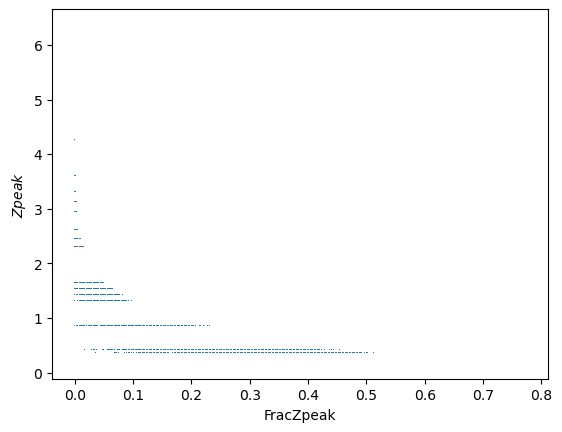

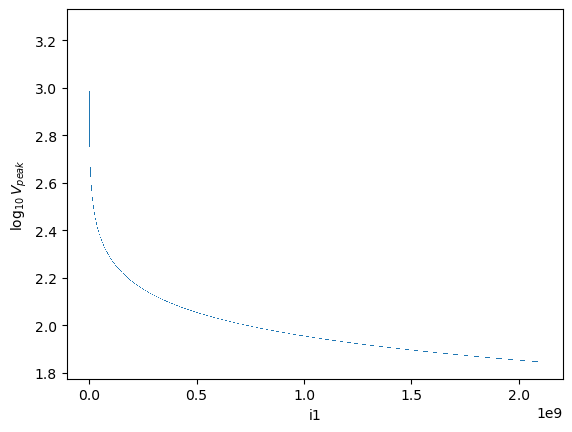

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


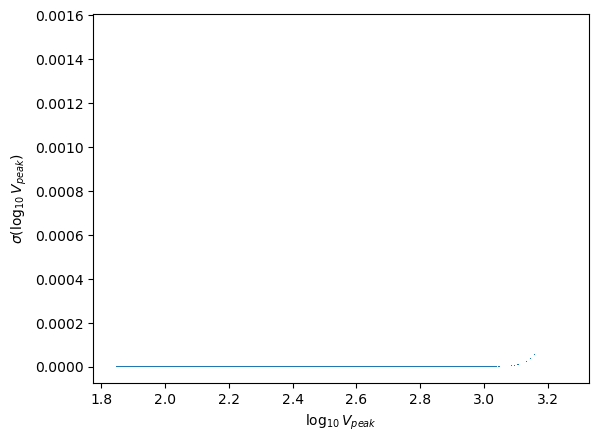

In [16]:
# Some temporary plots to check ranking works and scatter among neighbours is small
x = subhalos['i1']
logvp = np.log10(subhalos['Vpeak'])

# Choose sample size
N = 100_000  # adjust based on speed / visual density

# Random indices
idx = np.random.choice(len(x), size=N, replace=False)

zpeak=(1.0/subhalos['Mpeak_Scale'][idx])-1.0

x=subhalos['FracZpeak'][idx]
y=zpeak


# Plot
plt.scatter(x, y, marker=',',  s=0.1, edgecolors='none')

plt.xlabel('FracZpeak')
plt.ylabel(r'$Zpeak$')

plt.show()




# Extract columns
x = subhalos['i1']
logvp = np.log10(subhalos['Vpeak'])

# Subsample
x_s = x[idx]
logvp_s = logvp[idx]

# Plot
plt.scatter(x_s, logvp_s, marker=',',  s=0.1, edgecolors='none')

plt.xlabel('i1')
plt.ylabel(r'$\log_{10} V_{peak}$')

plt.show()


sigma=compute_scatter(logvp, N_neigh_vpeak)
sigma_s=sigma[idx]

# Scatter plot with pixel markers
plt.scatter(logvp_s, sigma_s, marker=',',s=0.1, edgecolors='none')

# Labels
plt.ylabel(r'$\sigma(\log_{10} V_{peak})$')
plt.xlabel(r'$\log_{10} V_{peak}$')


plt.show()

In [17]:
if readfulluuchu:
    start_time = time.time()
    # Reduce the size of the subhalo table by removing the objects with subhalos['keep']=False. Also deletes the 'keep' column
    subhalos = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    end_time = time.time()
    print(f"time to apply vpeak(distance) cut: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')

In [18]:
# Cut to an RA dec patch to have a small sample for tests
start_time = time.time()
subhalos["keep"]= (subhalos["RA"]>RAmin)  & (subhalos["RA"]<RAmax) & (subhalos["DEC"]>DECmin)  & (subhalos["DEC"]<DECmax) 
subhalos = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
end_time = time.time()
print(f"time to apply RA DEC selection: {end_time - start_time:.1f} seconds")


if verbose_stats: subhalos.info("stats")

time to apply RA DEC selection: 3.8 seconds


Uuchu number and box size: 18968152 2000.0


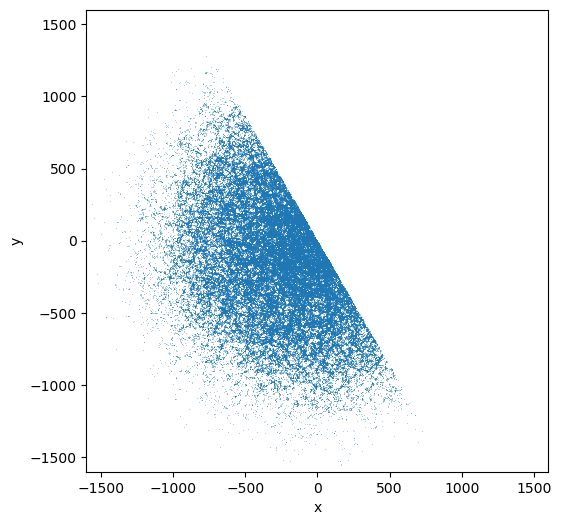

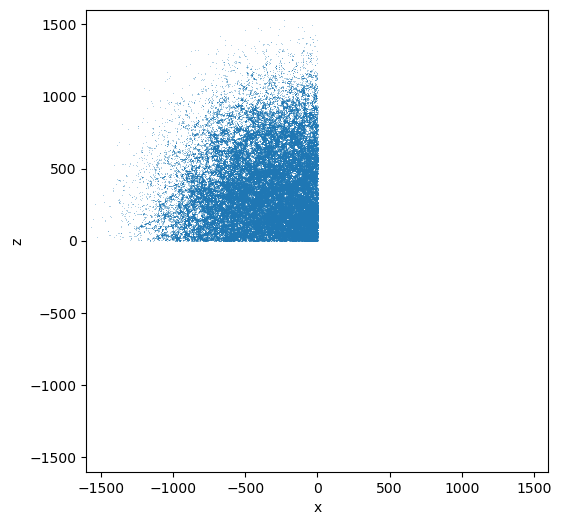

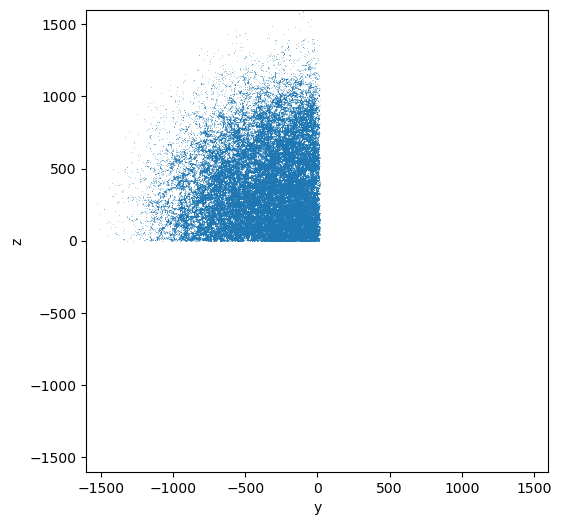

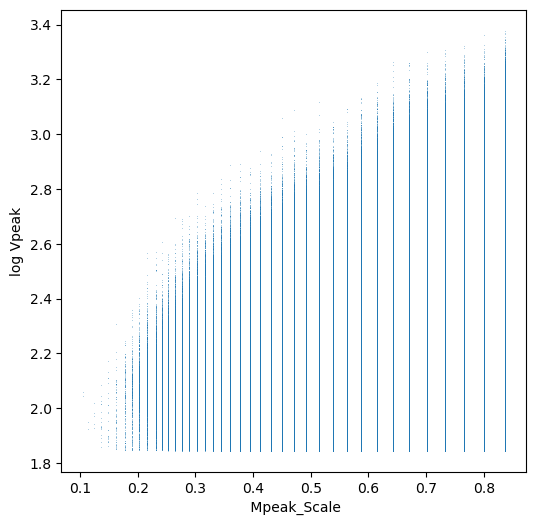

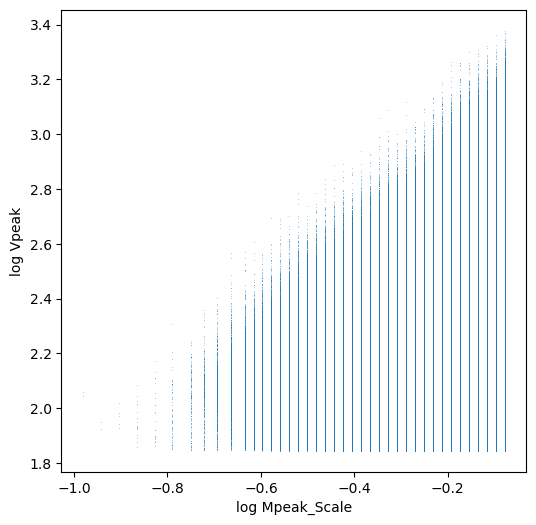

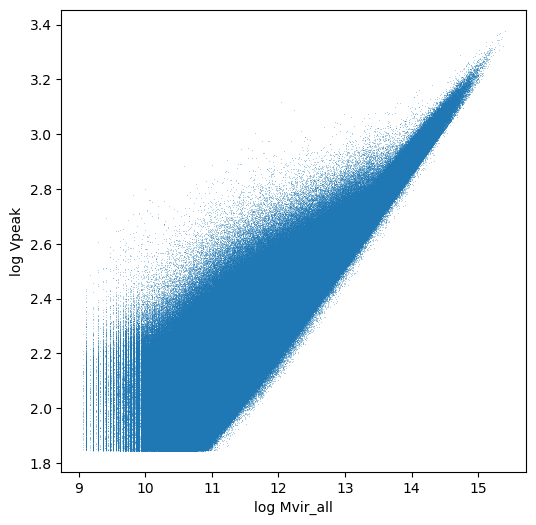

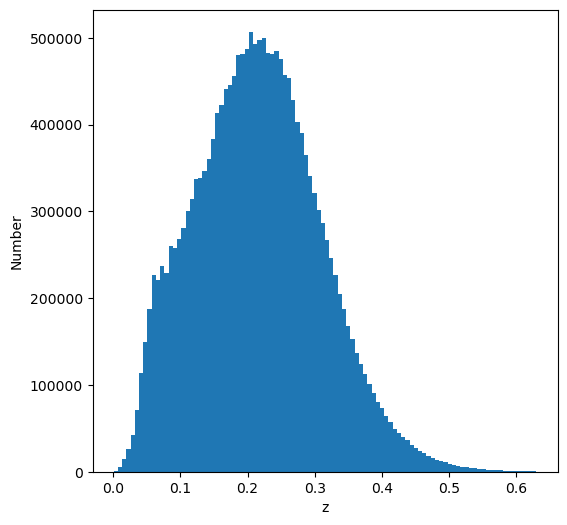

In [19]:
# Inspect uuchu dataset and define the redshift,RA, DEC and other parameters that we may use in matching



nbox=len(subhalos)
print('Uuchu number and box size:',nbox,lbox)



fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['z'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['y'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['y'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['x'])<10.0)
ax.scatter(subhalos['y'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()



# Inspect other properties such as the distribution of Vpeak and Mpeak_scale

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subhalos['Mpeak_Scale'],np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel(' Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mpeak_Scale']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mvir_all']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mvir_all')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(subhalos['Zu'],bins=100)
ax.set_xlabel('z')
ax.set_ylabel('Number')
fig.show()





In [20]:
#Write selected catalogue to disk for future use
if readfulluuchu:
    subhalos.meta["RAmin"]=RAmin  #store meta data with subhaloes so consistency can be checked.
    subhalos.meta["RAmax"]=RAmax
    subhalos.meta["DECmin"]=DECmin
    subhalos.meta["DECmax"]=DECmax 
    subhalos.meta["min_Vpeak"]=min_Vpeak 
    subhalos.write("sdata/subhalos70.fits",overwrite=True)



In [21]:
#Load the random catalogue into a astro-py table
start_time = time.time()
randoms=Table.read(rancat)
print('Meta data',randoms.meta)
if (reg=='S') :
    nmult=randoms.meta['NMULTS'] # This is the factor by which the density is higher in this random catalogue than the corresponding data
elif  (reg=='N') :
    nmult=randoms.meta['NMULTN'] # This is the factor by which the density is higher in this random catalogue than the corresponding data   
print('nmult=',nmult)
DeltaZ=randoms.meta["DELTAZ"]
print("DeltaZ=",DeltaZ)
regran=randoms.meta["REG"]
print("Random Catalogue was generated with the selection function of region ",regran)
assert regran == reg, f"Faint limits do not match: {regran} != {reg}"
#add and index/id
randoms['ID'] = np.arange(len(randoms), dtype=np.int64)
end_time = time.time()
print(f"time to read Randoms: {end_time - start_time:.1f} seconds")
if verbose_stats: randoms.info('stats')



Meta data {'EXTNAME': 'LSS', 'NMULTS': 12.003282460631205, 'DELTAZ': 0.03, 'REG': 'S'}
nmult= 12.003282460631205
DeltaZ= 0.03
Random Catalogue was generated with the selection function of region  S
time to read Randoms: 17.1 seconds


In [22]:
def abundance_match_subhalos_to_randoms(
    subhalos,
    ran,
    lbox,
    rsphere,
    fsky,
    z_bins,
    scatter_sigma=None,
    DeltaZ=0.03,
    lam=1.0
):
    """
    NumPy-based abundance matching with minimal memory overhead.
    """
    kcorr_r  = DESI_KCorrection(band='R', file='jmext', photsys=reg) 
    # ------------------------------------------------------------
    # Extract NumPy arrays (no copies yet)
    # ------------------------------------------------------------
    sub_id = subhalos['ID']
    sub_vpeak = subhalos['Vpeak']
    sub_z = subhalos['Zu']
    i1= subhalos['i1']

    ran_id = ran['ID']
    ran_mag=ran['ABSMAG_R']
    ran_gp = ran['ABSMAG_GP1']
    ran_rp = ran['ABSMAG_RP1']
    ran_rmag = ran['rmag']
    ran_z = ran['Z']
    ran_zmin = ran['zmin']
    ran_zmax = ran['zmax']


    # ------------------------------------------------------------
    # Sort randoms once by luminosity (brightest first)
    # ------------------------------------------------------------
    ran_order = np.argsort(ran_mag)  # more negative mag = brighter
    ran_id = ran_id[ran_order]
    ran_z = ran_z[ran_order]
    ran_zmin = ran_zmin[ran_order]
    ran_zmax = ran_zmax[ran_order]
    ran_gp = ran_gp[ran_order]
    ran_rp = ran_rp[ran_order]
    ran_mag =ran_mag[ran_order]
    

    # ------------------------------------------------------------
    # Output containers (column-wise, memory-efficient)
    # ------------------------------------------------------------
    out_sub = []
    out_gal = []

    V_sim = (4.0*np.pi/3.0)* (rsphere**3)  #Volume cut from simulatin box within which ranking was performed. Needed for scaling.

    # ------------------------------------------------------------
    # Loop over redshift slices
    # ------------------------------------------------------------
    for zmin, zmax in zip(z_bins[:-1], z_bins[1:]):

        zmin_ex=np.maximum(0.0,zmax-DeltaZ)
        # Boolean masks (cheap views)
        sub_m = (sub_z >= zmin) & (sub_z < zmax)
        ran_m = (ran_z >= zmin_ex) & (ran_z < zmax) & (ran_zmax>=zmax)
        
       
        if not sub_m.any() or not ran_m.any(): #If nothing in one or other slice move to next slice
            continue

        # Indices
        sub_idx = np.nonzero(sub_m)[0] #returns as a numpy array the indices of the subhaloes in the redshift slice i.e. for which the mask is True
        ran_idx = np.nonzero(ran_m)[0] #returns as a numpy array the indices of the random galaxies in the redshift slice i.e. for which the mask is True

        
        V_slice = fsky * (4.0*np.pi/3.0)*( (ca.cosmo.comoving_distance(zmax).value)**3 -(ca.cosmo.comoving_distance(zmin_ex).value)**3  ) #volume of shell in random catalogue
        R = V_sim / V_slice # volume ratio needed for scaling when making matches

        print("Processing slice:",zmin,"<z<",zmax,"Nsubs=",sub_m.sum(),"Nrans=",ran_m.sum(),' R=',R)

        # ------------------------------------------------------------
        # Compute local FRAC variable for randoms in this slice
        # ------------------------------------------------------------
        colour = (ran_gp[ran_idx] - ran_rp[ran_idx]).astype(np.float32)

        #????
        mags_local=np.asarray(ran_mag[ran_idx].astype(np.float64))
        sigma=compute_scatter(mags_local, N_neigh)
        print("Stats of magnitude spread within nearest", N_neigh, " neighbours in the redshift slice. Is the spread small enough?")
        print("Mean:   ", np.mean(sigma))
        print("Median: ", np.median(sigma))
        print("Std:    ", np.std(sigma))
        print("Min:    ", np.min(sigma))
        print("Max:    ", np.max(sigma))


        rand_frac = compute_frac_local(colour, N_neigh=N_neigh)

        # Flip so that large = "extreme" (matches Zpeak convention)
        rand_frac = 1.0 - rand_frac


        # ------------------------------------------------------------
        # Extract subhalo FRAC for this slice
        # ------------------------------------------------------------
        sub_frac_slice = subhalos['FracZpeak'][sub_idx].astype(np.float32)


        # ------------------------------------------------------------
        # Build target rank (same as original)
        # ------------------------------------------------------------
        target_rank = np.rint(i1[sub_idx] / R).astype(np.int64) - 1

        # ------------------------------------------------------------
        # Valid mask to avoid duplicating matches when we run out of targets
        # ------------------------------------------------------------
        valid = (target_rank >= 0) & (target_rank < len(ran_idx))

        if not np.any(valid):
            continue

        # Apply mask
        sub_idx_valid = sub_idx[valid]
        target_rank_valid = target_rank[valid]

        sub_frac_valid = sub_frac_slice[valid]

        # ------------------------------------------------------------
        # Matching
        # ------------------------------------------------------------
        match_local = match_2d_many_to_one(
            sub_frac_valid,
            rand_frac,
            target_rank_valid,
            W=50,
            lam=lam
        )
        
        # ------------------------------------------------------------
        # Map back to global indices
        # ------------------------------------------------------------
        matched_gal_ids = ran_id[ran_idx[match_local]]

        # ------------------------------------------------------------
        # Store results
        # ------------------------------------------------------------
        out_sub.extend(sub_id[sub_idx_valid])
        out_gal.extend(matched_gal_ids)

       


    # ------------------------------------------------------------
    # When all slices are processed return the complete matched list
    # as two corresponding numpy arrays
    # ------------------------------------------------------------
    return np.asarray(out_sub), np.asarray(out_gal)

In [23]:
#subhalos.rename_column('Z', 'Zu')

# Abundance match
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg) 
Sel=ca.selection(reg)
print('nmult=',nmult)
fsky=Sel['area']*nmult #fraction of sky covered by the random catalogue including the factor by which it oversamples


z_bins = np.linspace(Sel['zmin'], Sel['zmax'], nzbins)

start_time = time.time()

# Returns the id of each subhalo and the id of the galaxy it is matched with
subhalo_id,galaxy_id = abundance_match_subhalos_to_randoms(
    subhalos=subhalos,
    ran=randoms,
    lbox=lbox,        # simulation box size [Mpc/h]
    rsphere=rsphere,  # radius of sphere cut from the simulation
    fsky=fsky,        # effective fraction of sky covered by the random galaxy catalogue  
    z_bins=z_bins,    # redshift bin edges
    scatter_sigma=0.0, # dex scatter to add to Vpeak
    DeltaZ=DeltaZ,    #redshift limiter that was used when making the random catalogue
    lam=lam
)

end_time = time.time()
print(f"Elapsed time finding matches: {end_time - start_time:.4f} seconds")

Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
nmult= 12.003282460631205
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Processing slice: 0.002 <z< 0.00804040404040404 Nsubs= 857 Nrans= 35336  R= 118538.4705849855
Stats of magnitude spread within nearest 20  neighbours in the redshift slice. Is the spread small enough?
Mean:    6.031793e-05
Median:  3.469757e-07
Std:     0.0020281777
Min:     4.5833431e-10
Max:     0.2573861
Processing slice: 0.00804040404040404 <z< 0.014080808080808081 Nsubs= 6797 Nrans= 87706  R= 22165.152241360003
Stats of magnitude spread within nearest 20  neighbours in the redshift slice. Is the spread small enough?
Mean:    1.1713126e-05
Median:  5.142553e-08
Std:     0.0011733143
Min:     5.9745536e-10
Max:     0.33051842
Processing slice: 0.014080808080808081 <z< 0.020121212121212123 Nsubs= 15597 Nrans= 172815  R= 7628.837938562669
Stats of magnitude spread within nearest 20  neighbours in the redshift 

In [24]:
#create numpy array references to the IDs in the Tables
sub_ids = subhalos['ID']
ran_ids = randoms['ID']

# create indices to these arrays so as to put them in order of increasing ID
sub_sorter = np.argsort(sub_ids)
ran_sorter = np.argsort(ran_ids)

# hence produce versions of these arrays in which ID increases monotonically
sub_ids_sorted = sub_ids[sub_sorter]
ran_ids_sorted = ran_ids[ran_sorter]

# Do a vectorized search to find the rows that match the given list of IDs and then use the sorted arrays to map back to their position in the original arrays
sub_rows = sub_sorter[np.searchsorted(sub_ids_sorted, subhalo_id)]
gal_rows = ran_sorter[np.searchsorted(ran_ids_sorted, galaxy_id)]



In [25]:
# Add galaxy properties to the matched subhalos

#Set up arrays to recieve the values
nsub=len(subhalos)
Mr   = np.full(nsub,np.nan,dtype=np.float32)
Mrobs   = np.full(nsub,np.nan,dtype=np.float32)
rmag =np.full(nsub,np.nan,dtype=np.float32)
Mg   = np.full(nsub,np.nan,dtype=np.float32)
gmag =np.full(nsub,np.nan,dtype=np.float32)
Zr=np.full(nsub,np.nan,dtype=np.float32)


# copy or compute the required quantities for each matched row
Mr[sub_rows] =randoms['ABSMAG_RP1'][gal_rows]
Mrobs[sub_rows] =randoms['ABSMAG_R'][gal_rows]
Mg[sub_rows] =randoms['ABSMAG_GP1'][gal_rows]
Zr[sub_rows] = randoms['Z'][gal_rows]


DMOD=25.0+5.0*np.log10(ca.cosmo.luminosity_distance(randoms['Z'][gal_rows]).value) #compute distance modulus
rest_GMR= randoms['ABSMAG_GP1'][gal_rows]- randoms['ABSMAG_RP1'][gal_rows]  #rest frame colour
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg)   #set up r-band k-correction
Qr=Sel['Qr']  #compute r-band magnitude using appropriate k+e correction
rmag[sub_rows]=randoms['ABSMAG_RP1'][gal_rows]+DMOD-Qr*(randoms['Z'][gal_rows]-0.1)+kcorr_r.k(randoms['Z'][gal_rows],rest_GMR)
kcorr_g  = ca.DESI_KCorrection(band='G', file='jmext', photsys=reg)  #set up g-band k-correction
Qg=Sel['Qg'] #compute g-band magnitude using appropriate k+e correction
gmag[sub_rows]=randoms['ABSMAG_GP1'][gal_rows]+DMOD-Qg*(randoms['Z'][gal_rows]-0.1)+kcorr_g.k(randoms['Z'][gal_rows],rest_GMR)
     

#Add arrays to the subhalos table
subhalos["ABSMAG_RP1"]=Mr
subhalos["ABSMAG_R"]=Mrobs
subhalos["ABSMAG_GP1"]=Mg
subhalos["rmag"]=rmag
subhalos["gmag"]=gmag
subhalos["Zr"]=Zr



del DMOD,rest_GMR,Mr,Mg,rmag,gmag,Mrobs # deletes temporary arrays and redundant references

Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_S_gband_z01.dat


In [26]:
# Store the mock catalogue keeping only the subhaloes for which matches were made
mask = np.isfinite(subhalos['rmag'])
subhalos['keep']=mask
subhalos_matched = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')






In [27]:
#Write mock to disk after deleting a couple of columns
subhalos_matched.rename_column('Zu', 'Z') #label the mock redshift as simply Z in the output
subhalos_matched.remove_column('i1')
subhalos_matched.info('stats')
subhalos_matched.write(mockcat,overwrite=True)

<Table length=6556177>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 1.55717e+15 6.65382e+14  8.2529e+11 2.19875e+15
   Mvir_all 7.13012e+12 2.59159e+13 1.14458e+09  2.5503e+15
      Vpeak     271.785     150.318       70.05     2387.14
          x    -261.078     275.202     -1533.4      755.26
          y    -149.258     346.842    -1528.35     1287.39
          z     299.148     231.445       3e-05     1518.07
Mpeak_Scale    0.749655     0.12558     0.14869     0.83735
       dist     598.773     266.463     6.40969     1536.37
        DEC     32.5791     21.4166 8.25581e-06     89.9135
         RA     209.789     51.7307         120         300
       conc     13.5843     30.0524     1.00006     12515.5
          Z    0.213228    0.100554  0.00213912    0.599997
       Zobs    0.213224    0.100452  0.00146165    0.604597
  FracZpeak    0.350292    0.163094           0       0.762
 ABSMAG_RP1    -2

In [28]:
# Delete columns that aren't useful
randoms.remove_column('PHOTSYS')
randoms.remove_column('reg')
randoms.remove_column('v')
randoms.remove_column('zmin')
randoms.remove_column('zmax')
randoms.remove_column('ID')
randoms.remove_column('TARGETID')

# Generate RA and DEC that are randomly uniformly distributed within the specified
# RA and DEC limits
rng = np.random.default_rng()
nr=len(randoms)
randoms['RA']=RAmin+(RAmax-RAmin)*rng.random(nr) #uniform in RA
sindecmin= np.sin(np.deg2rad(DECmin))
sindecmax= np.sin(np.deg2rad(DECmax))
sindec=sindecmin+(sindecmax-sindecmin)*rng.random(nr)
randoms['DEC']=np.rad2deg(np.arcsin(sindec)) #uniform in sin(DEC) 

#Check stats
randoms.info('stats')

# Store resulting catalogue in the fits file
randoms.write('sdata/randoms6thAug.fits',overwrite=True)


<Table length=85274778>
   name      mean     std        min       max   
---------- -------- -------- ----------- --------
        RA  209.999  51.9653         120      300
       DEC  32.7028  21.5584 6.15327e-07  89.9957
ABSMAG_RP1 -20.2551  1.23569    -26.6367 -9.45675
  ABSMAG_R -20.2419  1.23048    -27.2369 -9.35363
ABSMAG_GP1 -19.4754  1.13524    -26.2511 -8.79542
         Z 0.214161 0.100648  0.00196303      0.6
      rmag  18.6477 0.790337     8.22187  19.6567
      gmag  19.6551 0.928075      9.0302  21.4954
